# Vegetation / climate time series, maps, and seasonality (standalone)

This notebook is a **copy** of **§6–§10** from `vegetation_analysis.ipynb`, plus the **minimal upstream steps** needed to build `df`, `d`, `d_bio`, and `bio`.

**Requirements:** `final4.csv` in this folder (`03_data_analysis/`). **Outputs:** figures under `../images/` (same paths as the main notebook).


---
## Prerequisite: load data and build site–month `bio`

*(Same code as the start of `vegetation_analysis.ipynb`.)*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


In [2]:
df = pd.read_csv('final4.csv')

In [3]:
cols = [
    "individualCount", "NDVI_raw", "LandCover_Class",
    "verbatimScientificName", "decimalLatitude", "decimalLongitude", 'eventDate'
]

d = df[cols].copy()
d["NDVI"] = pd.to_numeric(d["NDVI_raw"], errors="coerce") / 10000

In [4]:
# As there are 81102 null values in NDVI, we will drop those rows for our analysis
d = d.dropna(subset=["NDVI"])

In [5]:
d_bio = d[["verbatimScientificName", "NDVI", "LandCover_Class", "decimalLatitude", "decimalLongitude", "eventDate"]].copy()
d_bio["NDVI"] = pd.to_numeric(d_bio["NDVI"], errors="coerce")
d_bio["eventDate"] = pd.to_datetime(d_bio["eventDate"], errors="coerce")
d_bio = d_bio.dropna()

d_bio.head()

,verbatimScientificName,NDVI,LandCover_Class,decimalLatitude,decimalLongitude,eventDate
0,Anarhynchus alexandrinus,0.3792,10,9.058512,79.855020,2021-01-06
1,Columba livia,0.5692,13,6.927894,79.865005,2024-09-24
2,Hirundo rustica,0.7045,13,6.866285,79.931440,2024-12-23
3,Geokichla spiloptera,0.9506,8,7.401229,80.690730,2024-09-13
5,Corvus macrorhynchos,0.6989,10,5.983496,80.525480,2024-10-12


In [6]:
# Sampling unit: site + month (avoids pooling everything at site level only)
d_bio["site"] = d_bio["decimalLatitude"].round(3).astype(str) + "_" + d_bio["decimalLongitude"].round(3).astype(str)
d_bio["year_month"] = d_bio["eventDate"].dt.to_period("M").astype(str)
d_bio["sample_unit"] = d_bio["site"] + "_" + d_bio["year_month"]

d_bio.head()

# The code creates a unique sampling unit based on location (site) and time (month) so that biodiversity
# observations are analyzed at the site-month level instead of pooling all data from a site together.

,verbatimScientificName,NDVI,LandCover_Class,decimalLatitude,decimalLongitude,eventDate,site,year_month,sample_unit
0,Anarhynchus alexandrinus,0.3792,10,9.058512,79.855020,2021-01-06,9.059_79.855,2021-01,9.059_79.855_2021-01
1,Columba livia,0.5692,13,6.927894,79.865005,2024-09-24,6.928_79.865,2024-09,6.928_79.865_2024-09
2,Hirundo rustica,0.7045,13,6.866285,79.931440,2024-12-23,6.866_79.931,2024-12,6.866_79.931_2024-12
3,Geokichla spiloptera,0.9506,8,7.401229,80.690730,2024-09-13,7.401_80.691,2024-09,7.401_80.691_2024-09
5,Corvus macrorhynchos,0.6989,10,5.983496,80.525480,2024-10-12,5.983_80.525,2024-10,5.983_80.525_2024-10


In [7]:
# Per-sample biodiversity metrics
richness = d_bio.groupby("sample_unit")["verbatimScientificName"].nunique().rename("species_richness")

# It groups the dataset by sample_unit (site + month) and counts the number of unique species names 
# (verbatimScientificName) recorded in each unit using nunique(). The result is stored as a new 
# variable called species_richness, which represents the number of different species observed in 
# each sampling unit.


In [8]:
# Shannon diversity

def shannon_index(species_series):
    counts = species_series.value_counts()  # Count occurrences of each species
    p = counts / counts.sum() # Convert counts to proportions
    return float(-(p * np.log(p)).sum()) # Shannon index formula

shannon = d_bio.groupby("sample_unit")["verbatimScientificName"].apply(shannon_index).rename("shannon")

In [9]:
# Vegetation summary per sample unit

# This code creates a table per site-month combining biodiversity metrics (richness, Shannon index)
# with vegetation data (mean NDVI, dominant land cover) for analysis.

veg = d_bio.groupby("sample_unit").agg(
    mean_ndvi=("NDVI", "mean"), # Average NDVI per unit
    landcover_mode=("LandCover_Class", lambda x: x.mode().iloc[0]) # Most common land cover
)

bio = pd.concat([richness, shannon, veg], axis=1).dropna()

---
## Copied from main notebook: §6 through §10

*(Cells are unchanged apart from clearing outputs.)*

## 6. Time series: climate, vegetation, and bird responses

National-scale monthly aggregates from the same observation rows: NDVI, rainfall, and **bird metrics** — distinct species observed in the month (national pool), mean `individualCount` per record, and number of records (sampling effort). **Caveat:** species counts and record totals reflect both ecology and **observer effort / coverage**; interpret as descriptive co-variation, not causal effects.

We plot climate and vegetation alongside bird metrics, then use lagged cross-correlations: NDVI vs rainfall (green-up vs rain), and bird metrics vs NDVI or rainfall (birds as potential responses to seasonal conditions).

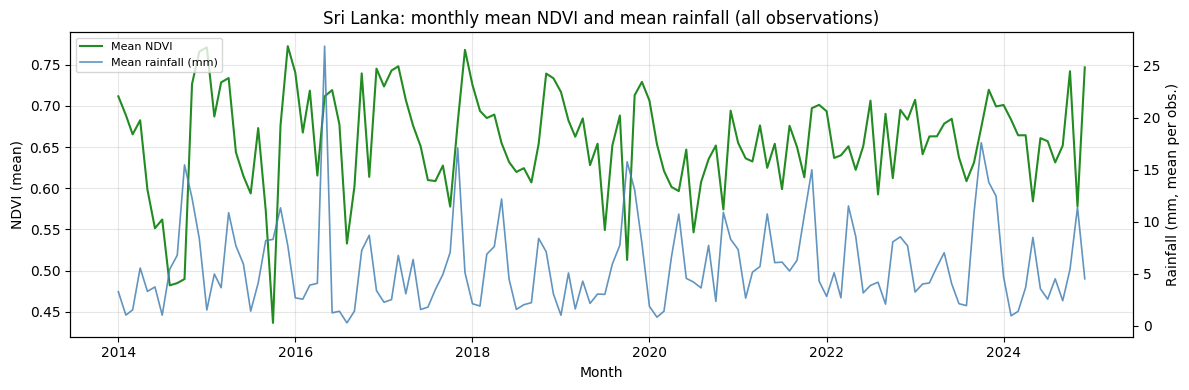

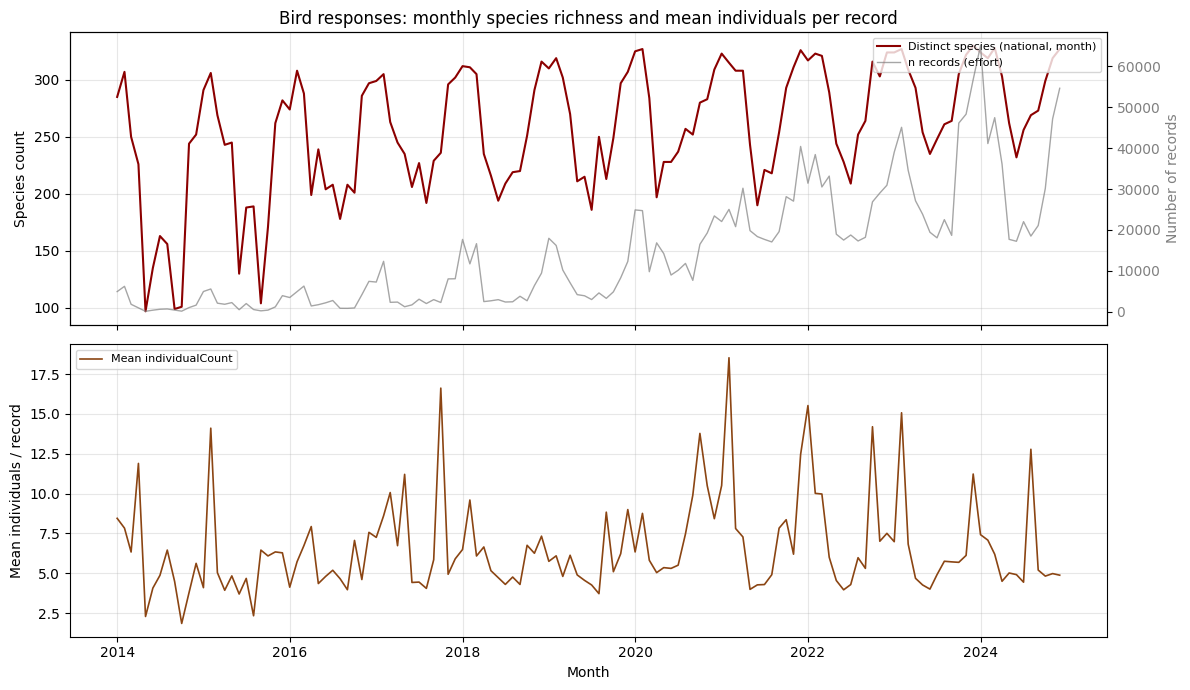

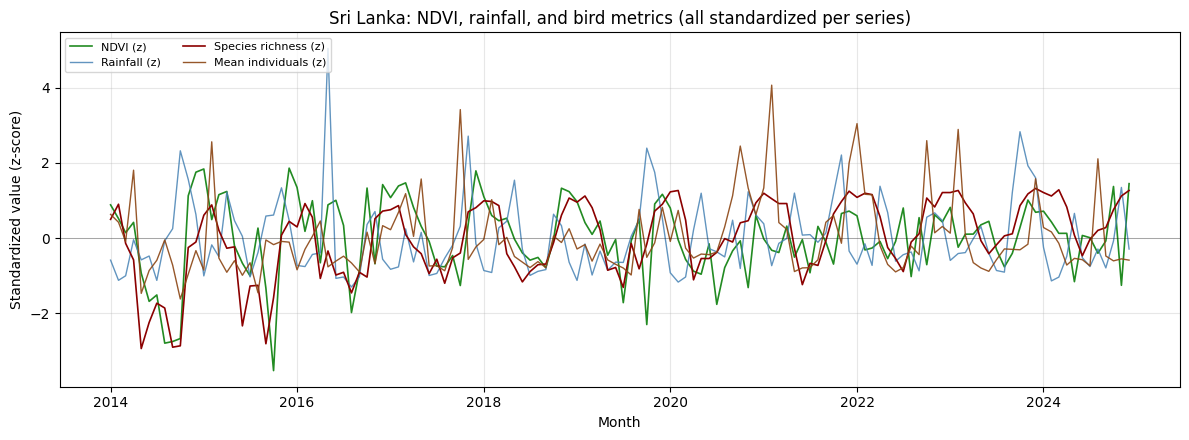

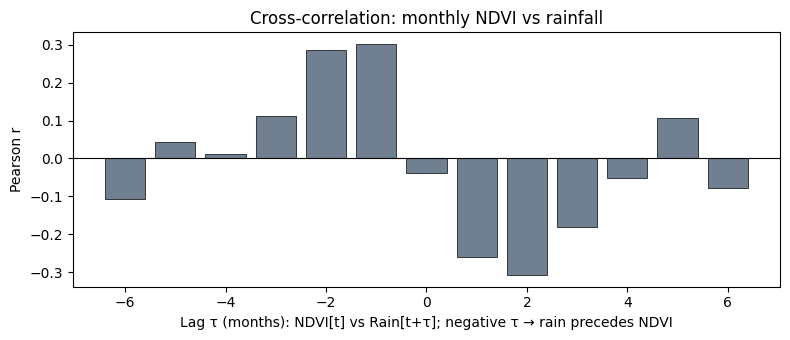

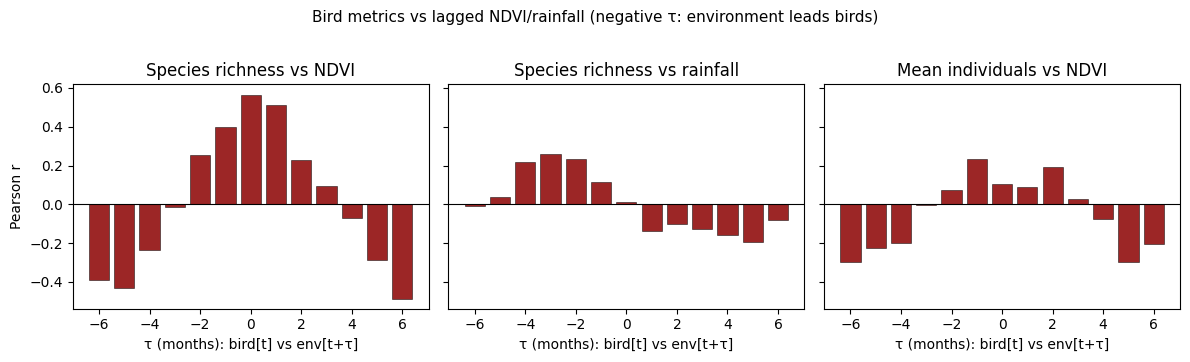

Peak |r| lag (months), r — richness vs NDVI: (0, 0.5660988150451471)
Peak |r| lag (months), r — richness vs rain: (-3, 0.2611086115741684)
Peak |r| lag (months), r — mean individuals vs NDVI: (5, -0.2993171431811695)


In [10]:
# Monthly NDVI, rainfall, and bird metrics (same observation rows)
df_ts = df.copy()
df_ts["eventDate"] = pd.to_datetime(df_ts["eventDate"], errors="coerce")
df_ts = df_ts.dropna(subset=["eventDate", "NDVI_raw"])
df_ts["NDVI"] = df_ts["NDVI_raw"] / 10000.0
df_ts["year_month"] = df_ts["eventDate"].dt.to_period("M")

monthly = (
    df_ts.groupby("year_month", as_index=False)
    .agg(
        NDVI_mean=("NDVI", "mean"),
        rainfall_mean=("rainfall", "mean"),
        n_obs=("NDVI", "count"),
        species_n_month=("verbatimScientificName", lambda s: s.dropna().nunique()),
        mean_individual=("individualCount", "mean"),
    )
    .sort_values("year_month")
)
monthly["date"] = monthly["year_month"].dt.to_timestamp()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(monthly["date"], monthly["NDVI_mean"], color="forestgreen", lw=1.5, label="Mean NDVI")
ax1.set_ylabel("NDVI (mean)")
ax1.set_xlabel("Month")
ax1.grid(alpha=0.3)

ax2 = ax1.twinx()
ax2.plot(monthly["date"], monthly["rainfall_mean"], color="steelblue", lw=1.2, alpha=0.85, label="Mean rainfall (mm)")
ax2.set_ylabel("Rainfall (mm, mean per obs.)")

lines1, lab1 = ax1.get_legend_handles_labels()
lines2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, lab1 + lab2, loc="upper left", fontsize=8)
plt.title("Sri Lanka: monthly mean NDVI and mean rainfall (all observations)")
plt.tight_layout()
plt.savefig("images/veg_fig_ts_ndvi_rain.png", dpi=150, bbox_inches="tight")
plt.show()

# Bird metrics vs time (national monthly pool; n_obs = sampling intensity)
fig, (axb1, axb2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
axb1.plot(monthly["date"], monthly["species_n_month"], color="darkred", lw=1.5, label="Distinct species (national, month)")
axb1.set_ylabel("Species count")
axb1.grid(alpha=0.3)
axb1.legend(loc="upper left", fontsize=8)
axb1.set_title("Bird responses: monthly species richness and mean individuals per record")
axb1b = axb1.twinx()
axb1b.plot(monthly["date"], monthly["n_obs"], color="gray", lw=1, alpha=0.7, label="n records (effort)")
axb1b.set_ylabel("Number of records", color="gray")
axb1b.tick_params(axis="y", labelcolor="gray")
l1, la1 = axb1.get_legend_handles_labels()
l2, la2 = axb1b.get_legend_handles_labels()
axb1.legend(l1 + l2, la1 + la2, loc="upper right", fontsize=8)

axb2.plot(monthly["date"], monthly["mean_individual"], color="saddlebrown", lw=1.2, label="Mean individualCount")
axb2.set_ylabel("Mean individuals / record")
axb2.set_xlabel("Month")
axb2.grid(alpha=0.3)
axb2.legend(loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("images/veg_fig_ts_birds_monthly.png", dpi=150, bbox_inches="tight")
plt.show()

# Overlay: environment vs birds (z-score each series for comparable scale)
def zscore(x):
    x = np.asarray(x, dtype=float)
    m, s = np.nanmean(x), np.nanstd(x)
    if s == 0 or not np.isfinite(s):
        return np.zeros_like(x)
    return (x - m) / s

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(monthly["date"], zscore(monthly["NDVI_mean"]), color="forestgreen", lw=1.2, label="NDVI (z)")
ax.plot(monthly["date"], zscore(monthly["rainfall_mean"]), color="steelblue", lw=1.0, alpha=0.85, label="Rainfall (z)")
ax.plot(monthly["date"], zscore(monthly["species_n_month"]), color="darkred", lw=1.2, label="Species richness (z)")
ax.plot(monthly["date"], zscore(monthly["mean_individual"]), color="saddlebrown", lw=1.0, alpha=0.9, label="Mean individuals (z)")
ax.set_ylabel("Standardized value (z-score)")
ax.set_xlabel("Month")
ax.axhline(0, color="black", lw=0.5, alpha=0.4)
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.set_title("Sri Lanka: NDVI, rainfall, and bird metrics (all standardized per series)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/veg_fig_ts_birds_env_z.png", dpi=150, bbox_inches="tight")
plt.show()

ndvi_s = monthly["NDVI_mean"].values.astype(float)
rain_s = monthly["rainfall_mean"].values.astype(float)
rich_s = monthly["species_n_month"].values.astype(float)
ind_s = monthly["mean_individual"].values.astype(float)


def pearson_lag(a, b, tau):
    n = len(a)
    if tau >= 0:
        x, y = a[: n - tau], b[tau:]
    else:
        tau = -tau
        x, y = a[tau:], b[: n - tau]
    m = np.isfinite(x) & np.isfinite(y)
    x, y = x[m], y[m]
    if len(x) < 4:
        return np.nan
    return np.corrcoef(x, y)[0, 1]


max_lag = 6
lags = np.arange(-max_lag, max_lag + 1)

# NDVI vs rainfall (negative tau => rain leads NDVI)
ccf_nr = np.array([pearson_lag(ndvi_s, rain_s, tau) for tau in lags])
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.bar(lags, ccf_nr, color="slategray", edgecolor="black", linewidth=0.5)
ax.axhline(0, color="black", lw=0.8)
ax.set_xlabel("Lag τ (months): NDVI[t] vs Rain[t+τ]; negative τ → rain precedes NDVI")
ax.set_ylabel("Pearson r")
ax.set_title("Cross-correlation: monthly NDVI vs rainfall")
plt.tight_layout()
plt.savefig("images/veg_fig_ts_ccf.png", dpi=150, bbox_inches="tight")
plt.show()

# Birds as responses: correlate bird[t] with NDVI[t+tau] and Rain[t+tau]
# (same indexing as above: response a vs predictor b at lag tau)
ccf_r_ndvi = np.array([pearson_lag(rich_s, ndvi_s, tau) for tau in lags])
ccf_r_rain = np.array([pearson_lag(rich_s, rain_s, tau) for tau in lags])
ccf_i_ndvi = np.array([pearson_lag(ind_s, ndvi_s, tau) for tau in lags])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.5), sharey=True)
for ax, ccf, title in zip(
    axes,
    [ccf_r_ndvi, ccf_r_rain, ccf_i_ndvi],
    [
        "Species richness vs NDVI",
        "Species richness vs rainfall",
        "Mean individuals vs NDVI",
    ],
):
    ax.bar(lags, ccf, color="darkred", edgecolor="black", linewidth=0.4, alpha=0.85)
    ax.axhline(0, color="black", lw=0.8)
    ax.set_xlabel("τ (months): bird[t] vs env[t+τ]")
    ax.set_title(title)
axes[0].set_ylabel("Pearson r")
fig.suptitle(
    "Bird metrics vs lagged NDVI/rainfall (negative τ: environment leads birds)",
    fontsize=11,
    y=1.02,
)
plt.tight_layout()
plt.savefig("images/veg_fig_ts_ccf_birds.png", dpi=150, bbox_inches="tight")
plt.show()

def argmax_lag(ccf_arr):
    i = np.nanargmax(np.abs(ccf_arr))
    return int(lags[i]), float(ccf_arr[i])

print("Peak |r| lag (months), r — richness vs NDVI:", argmax_lag(ccf_r_ndvi))
print("Peak |r| lag (months), r — richness vs rain:", argmax_lag(ccf_r_rain))
print("Peak |r| lag (months), r — mean individuals vs NDVI:", argmax_lag(ccf_i_ndvi))

## 7. Monthly NDVI by land cover (major IGBP classes)

Multi-line plot: mean NDVI per calendar month, stratified by the most common MODIS land-cover classes in the dataset (classes with sufficient monthly coverage).

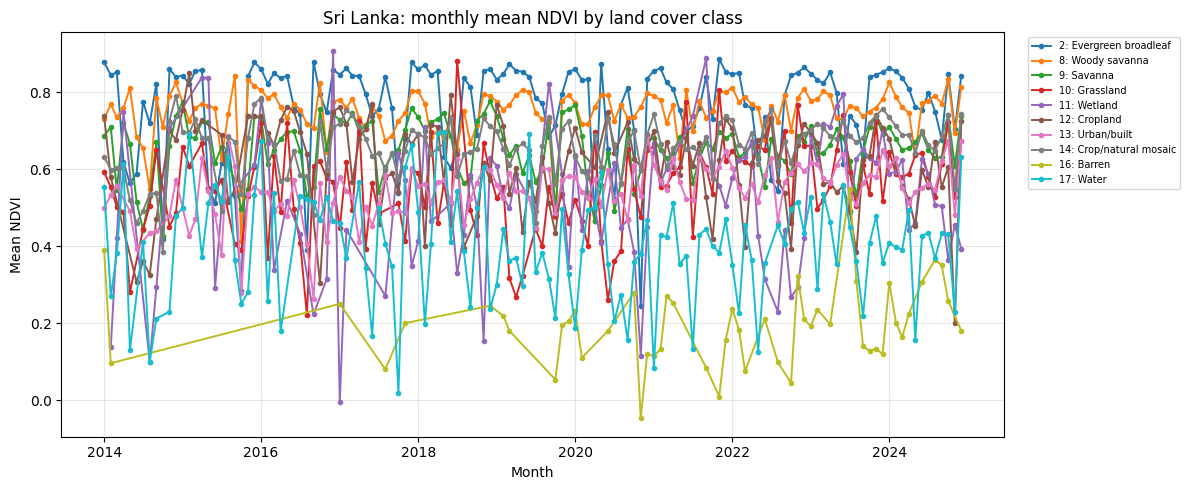

In [11]:
# Monthly mean NDVI per LandCover_Class
lc_ts = df_ts.copy()
lc_counts = lc_ts["LandCover_Class"].value_counts()
top_lc = lc_counts[lc_counts >= 500].index.tolist()
if len(top_lc) < 3:
    top_lc = lc_counts.head(8).index.tolist()
lc_ts = lc_ts[lc_ts["LandCover_Class"].isin(top_lc)]

lc_monthly = (
    lc_ts.groupby(["year_month", "LandCover_Class"], as_index=False)
    .agg(NDVI_mean=("NDVI", "mean"), n=("NDVI", "count"))
)
lc_monthly["date"] = lc_monthly["year_month"].dt.to_timestamp()

IGBP_SHORT = {
    1: "Evergreen needle",
    2: "Evergreen broadleaf",
    3: "Deciduous needle",
    4: "Deciduous broadleaf",
    5: "Mixed forest",
    6: "Closed shrub",
    7: "Open shrub",
    8: "Woody savanna",
    9: "Savanna",
    10: "Grassland",
    11: "Wetland",
    12: "Cropland",
    13: "Urban/built",
    14: "Crop/natural mosaic",
    15: "Snow/ice",
    16: "Barren",
    17: "Water",
}

fig, ax = plt.subplots(figsize=(12, 5))
for lc in sorted(lc_monthly["LandCover_Class"].unique()):
    sub = lc_monthly[lc_monthly["LandCover_Class"] == lc].sort_values("date")
    label = IGBP_SHORT.get(int(lc), f"class {lc}")
    ax.plot(sub["date"], sub["NDVI_mean"], lw=1.4, marker="o", ms=3, label=f"{lc}: {label}")

ax.set_ylabel("Mean NDVI")
ax.set_xlabel("Month")
ax.set_title("Sri Lanka: monthly mean NDVI by land cover class")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=7)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/veg_fig_ndvi_by_landcover_months.png", dpi=150, bbox_inches="tight")
plt.show()

## 8. Species richness vs NDVI *within* land cover

Site–month units (`bio`): Spearman (and Pearson) correlation between `species_richness` and `mean_ndvi`, computed separately for each `landcover_mode`. This avoids masking opposite slopes across habitats when pooling globally.

   LandCover  n_units  Spearman_rho  Spearman_p  Pearson_r  Pearson_p
0          2     3731        0.0502      0.0021     0.0617     0.0002
1          8     8790        0.0377      0.0004     0.0081     0.4471
2          9     6885        0.0365      0.0024     0.0696     0.0000
3         10     2022        0.0319      0.1515     0.0381     0.0870
4         11      454        0.0587      0.2122     0.0618     0.1888
5         12      971       -0.0417      0.1943    -0.0680     0.0342
6         13     6379        0.2069      0.0000     0.2229     0.0000
7         14     6319       -0.0173      0.1701    -0.0378     0.0027
8         16       92       -0.1839      0.0794    -0.1472     0.1614
9         17     1135        0.0073      0.8062     0.0070     0.8129


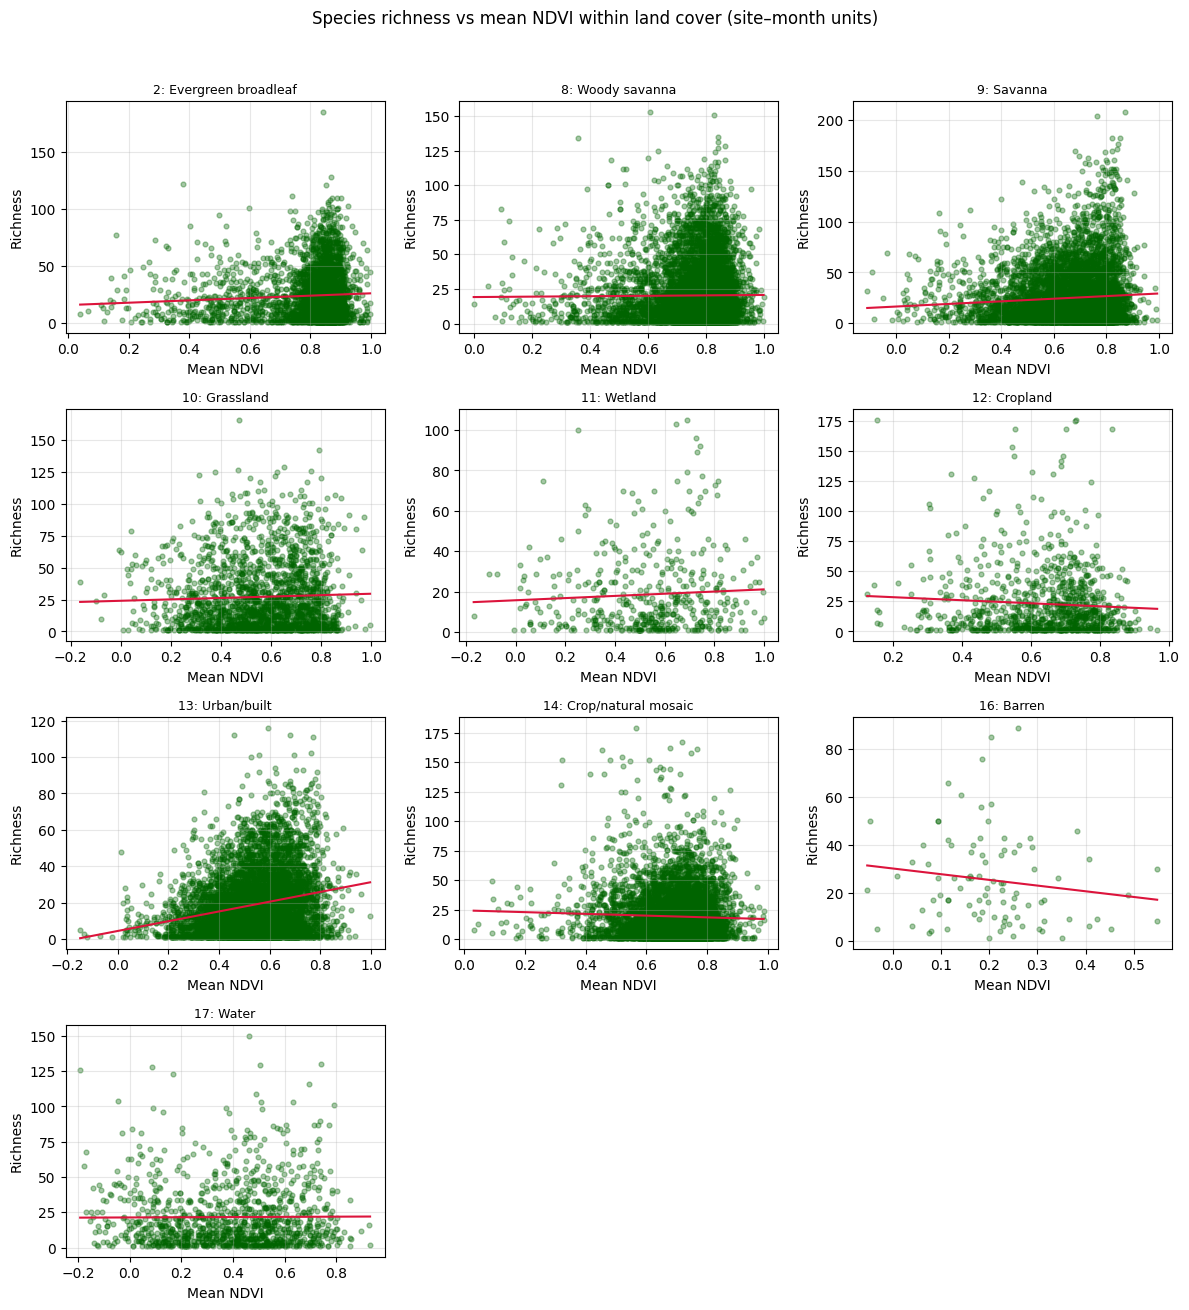

In [12]:
rows = []
for lc, g in bio.dropna(subset=["mean_ndvi", "species_richness"]).groupby("landcover_mode"):
    if len(g) < 30:
        continue
    r_s, p_s = stats.spearmanr(g["mean_ndvi"], g["species_richness"])
    r_p, p_p = stats.pearsonr(g["mean_ndvi"], g["species_richness"])
    rows.append(
        {
            "LandCover": lc,
            "n_units": len(g),
            "Spearman_rho": r_s,
            "Spearman_p": p_s,
            "Pearson_r": r_p,
            "Pearson_p": p_p,
        }
    )

rich_ndvi_lc = pd.DataFrame(rows).sort_values("LandCover")
pd.set_option("display.max_rows", 30)
print(rich_ndvi_lc.round(4).to_string())

# Small multiples: richness vs NDVI
g_lc = bio.groupby("landcover_mode").size()
plot_classes = g_lc[g_lc >= 40].index.tolist()
n_p = len(plot_classes)
if n_p == 0:
    print("No land cover class with >=40 site–month units for facet plot.")
else:
    ncols = min(3, n_p)
    nrows = int(np.ceil(n_p / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 3.2 * nrows), squeeze=False)
    for i, lc in enumerate(plot_classes):
        r, c = divmod(i, ncols)
        ax = axes[r][c]
        sub = bio[bio["landcover_mode"] == lc]
        ax.scatter(sub["mean_ndvi"], sub["species_richness"], alpha=0.35, s=12, color="darkgreen")
        if len(sub) >= 10:
            z = np.polyfit(sub["mean_ndvi"], sub["species_richness"], 1)
            xs = np.linspace(sub["mean_ndvi"].min(), sub["mean_ndvi"].max(), 50)
            ax.plot(xs, np.poly1d(z)(xs), color="crimson", lw=1.5)
        lbl = IGBP_SHORT.get(int(lc), str(lc))
        ax.set_title(f"{lc}: {lbl}", fontsize=9)
        ax.set_xlabel("Mean NDVI")
        ax.set_ylabel("Richness")
        ax.grid(alpha=0.3)
    for j in range(i + 1, nrows * ncols):
        r, c = divmod(j, ncols)
        axes[r][c].set_visible(False)
    plt.suptitle("Species richness vs mean NDVI within land cover (site–month units)", y=1.02)
    plt.tight_layout()
    plt.savefig("images/veg_fig_richness_ndvi_facets.png", dpi=150, bbox_inches="tight")
    plt.show()

## 9. Sri Lanka–extent maps (lat/lon)

Hexbin density maps use observation coordinates clipped to Sri Lanka bounds; avoids overplotting millions of points. No political boundary layer (would require GeoJSON/cartopy); axes are geographic WGS84.

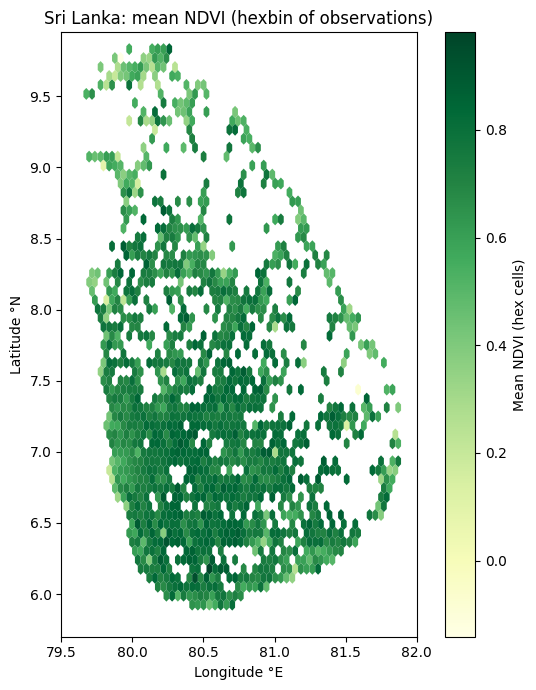

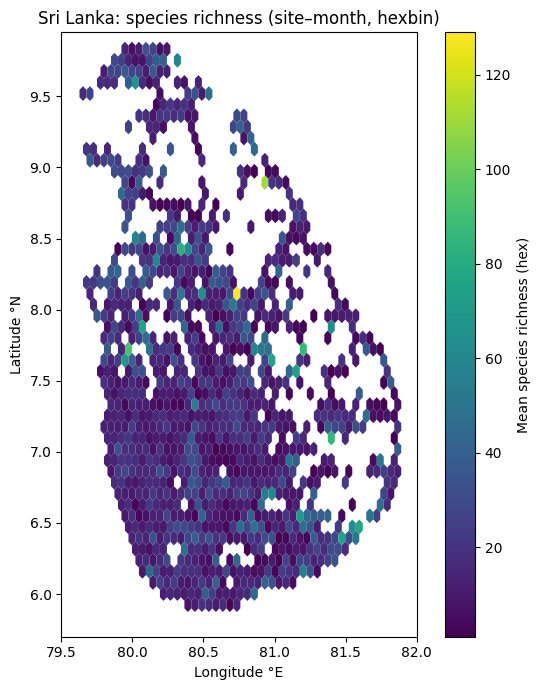

In [13]:
# Sri Lanka approximate bounding box (WGS84)
LON_MIN, LON_MAX = 79.5, 82.0
LAT_MIN, LAT_MAX = 5.7, 9.95

map_df = df.loc[
    (df["decimalLongitude"] >= LON_MIN)
    & (df["decimalLongitude"] <= LON_MAX)
    & (df["decimalLatitude"] >= LAT_MIN)
    & (df["decimalLatitude"] <= LAT_MAX)
].copy()
map_df = map_df.dropna(subset=["NDVI_raw", "decimalLatitude", "decimalLongitude"])
map_df["NDVI"] = map_df["NDVI_raw"] / 10000.0

rng = np.random.default_rng(42)
n_hex = min(120_000, len(map_df))
idx = rng.choice(len(map_df), size=n_hex, replace=False)
m = map_df.iloc[idx]

fig, ax = plt.subplots(figsize=(6, 7))
hb = ax.hexbin(
    m["decimalLongitude"],
    m["decimalLatitude"],
    C=m["NDVI"],
    reduce_C_function=np.mean,
    gridsize=55,
    cmap="YlGn",
    mincnt=1,
    linewidths=0,
)
cb = plt.colorbar(hb, ax=ax, label="Mean NDVI (hex cells)")
ax.set_xlabel("Longitude °E")
ax.set_ylabel("Latitude °N")
ax.set_title("Sri Lanka: mean NDVI (hexbin of observations)")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.savefig("images/veg_fig_map_ndvi_hexbin.png", dpi=150, bbox_inches="tight")
plt.show()

# Richness at site–month level mapped (subsample grid cells)
bio_map = bio.reset_index()
site_latlon = d_bio.drop_duplicates("sample_unit")[
    ["sample_unit", "decimalLatitude", "decimalLongitude"]
]
bio_map = bio_map.merge(site_latlon, on="sample_unit", how="left")
bio_map = bio_map.dropna(subset=["decimalLatitude", "decimalLongitude"])
bio_map = bio_map[
    (bio_map["decimalLongitude"] >= LON_MIN)
    & (bio_map["decimalLongitude"] <= LON_MAX)
    & (bio_map["decimalLatitude"] >= LAT_MIN)
    & (bio_map["decimalLatitude"] <= LAT_MAX)
]
nr = min(25_000, len(bio_map))
idx2 = rng.choice(len(bio_map), size=nr, replace=False)
bm = bio_map.iloc[idx2]

fig, ax = plt.subplots(figsize=(6, 7))
hb2 = ax.hexbin(
    bm["decimalLongitude"],
    bm["decimalLatitude"],
    C=bm["species_richness"],
    reduce_C_function=np.mean,
    gridsize=45,
    cmap="viridis",
    mincnt=1,
    linewidths=0,
)
plt.colorbar(hb2, ax=ax, label="Mean species richness (hex)")
ax.set_xlabel("Longitude °E")
ax.set_ylabel("Latitude °N")
ax.set_title("Sri Lanka: species richness (site–month, hexbin)")
ax.set_xlim(LON_MIN, LON_MAX)
ax.set_ylim(LAT_MIN, LAT_MAX)
ax.set_aspect("equal", adjustable="box")
plt.tight_layout()
plt.savefig("images/veg_fig_map_richness_hexbin.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. Seasonal patterns (month-of-year)

How NDVI, rainfall, and bird metrics **vary within a typical year**, not along the calendar timeline. We first aggregate to **(year × calendar month)**, then summarize across years so one wet/dry year does not dominate. **Caveat:** `n_obs` still reflects seasonal sampling; interpret bird peaks alongside effort.

In [14]:
# Working table: dates, NDVI, calendar month, year
ds = df.copy()
ds["eventDate"] = pd.to_datetime(ds["eventDate"], errors="coerce")
ds = ds.dropna(subset=["eventDate", "NDVI_raw"])
ds["NDVI"] = ds["NDVI_raw"] / 10000.0
ds["year"] = ds["eventDate"].dt.year
ds["cal_month"] = ds["eventDate"].dt.month


Per **year** and **calendar month** (1–12): mean environment, national species pool, mean individuals per record, and record count.

In [15]:
ym = (
    ds.groupby(["year", "cal_month"], as_index=False)
    .agg(
        NDVI_mean=("NDVI", "mean"),
        rainfall_mean=("rainfall", "mean"),
        n_obs=("NDVI", "count"),
        species_n=("verbatimScientificName", lambda s: s.dropna().nunique()),
        mean_individual=("individualCount", "mean"),
    )
    .sort_values(["year", "cal_month"])
)

Across years: **mean** of those monthly values for each calendar month (seasonal profile), with **standard error** of the mean for the line plots.

In [16]:
def se_mean(x):
    x = np.asarray(x, dtype=float)
    x = x[np.isfinite(x)]
    if len(x) < 2:
        return np.nan
    return float(np.std(x, ddof=1) / np.sqrt(len(x)))


seasonal = (
    ym.groupby("cal_month", as_index=False)
    .agg(
        NDVI_mean=("NDVI_mean", "mean"),
        NDVI_se=("NDVI_mean", se_mean),
        rainfall_mean=("rainfall_mean", "mean"),
        rainfall_se=("rainfall_mean", se_mean),
        n_obs_mean=("n_obs", "mean"),
        species_n_mean=("species_n", "mean"),
        species_n_se=("species_n", se_mean),
        mean_individual_mean=("mean_individual", "mean"),
        mean_individual_se=("mean_individual", se_mean),
    )
    .sort_values("cal_month")
)

**Line plot:** mean NDVI and rainfall by month ± SE (across years).

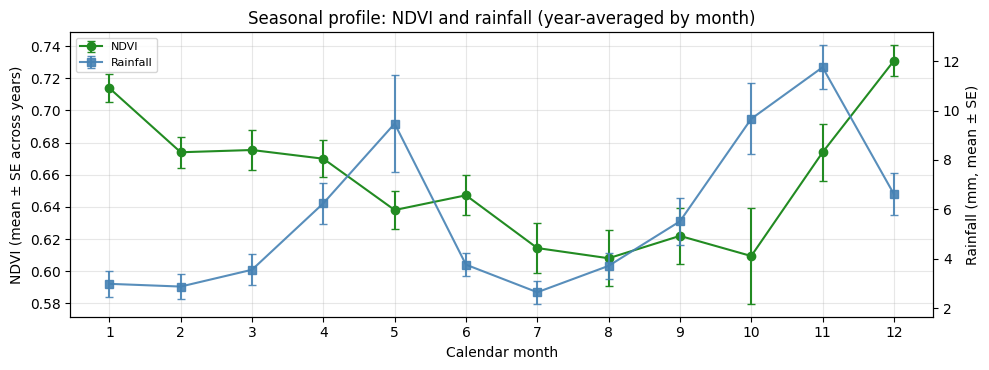

In [17]:
months = seasonal["cal_month"].values
x = np.arange(1, 13)
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.errorbar(
    months,
    seasonal["NDVI_mean"],
    yerr=seasonal["NDVI_se"],
    fmt="-o",
    color="forestgreen",
    capsize=3,
    label="NDVI",
)
ax.set_xticks(x)
ax.set_xlabel("Calendar month")
ax.set_ylabel("NDVI (mean ± SE across years)")
ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.errorbar(
    months,
    seasonal["rainfall_mean"],
    yerr=seasonal["rainfall_se"],
    fmt="-s",
    color="steelblue",
    capsize=3,
    alpha=0.9,
    label="Rainfall",
)
ax2.set_ylabel("Rainfall (mm, mean ± SE)")
ax.set_title("Seasonal profile: NDVI and rainfall (year-averaged by month)")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
plt.tight_layout()
plt.savefig("images/veg_fig_seasonal_ndvi_rain.png", dpi=150, bbox_inches="tight")
plt.show()

**Bird metrics** by month (mean ± SE across years); **sampling effort** (`n_obs` mean) on a twin axis.

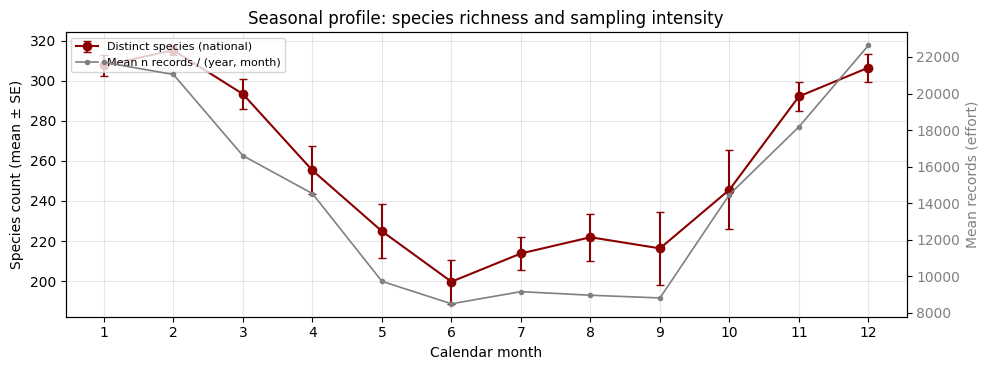

In [18]:
fig, ax = plt.subplots(figsize=(10, 3.8))
ax.errorbar(
    months,
    seasonal["species_n_mean"],
    yerr=seasonal["species_n_se"],
    fmt="-o",
    color="darkred",
    capsize=3,
    label="Distinct species (national)",
)
ax.set_xticks(x)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Species count (mean ± SE)")
ax.grid(alpha=0.3)
ax2 = ax.twinx()
ax2.plot(months, seasonal["n_obs_mean"], color="gray", lw=1.2, marker=".", label="Mean n records / (year, month)")
ax2.set_ylabel("Mean records (effort)", color="gray")
ax2.tick_params(axis="y", labelcolor="gray")
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, loc="upper left", fontsize=8)
ax.set_title("Seasonal profile: species richness and sampling intensity")
plt.tight_layout()
plt.savefig("images/veg_fig_seasonal_richness_effort.png", dpi=150, bbox_inches="tight")
plt.show()

Mean **individualCount** per record by month (± SE).

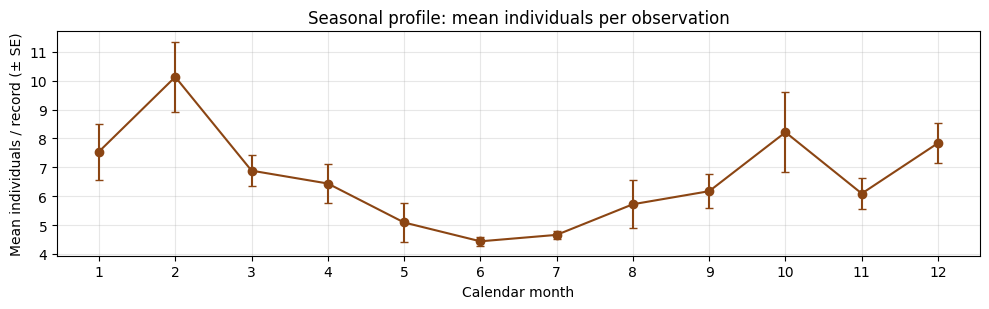

In [19]:
fig, ax = plt.subplots(figsize=(10, 3.2))
ax.errorbar(
    months,
    seasonal["mean_individual_mean"],
    yerr=seasonal["mean_individual_se"],
    fmt="-o",
    color="saddlebrown",
    capsize=3,
)
ax.set_xticks(x)
ax.set_xlabel("Calendar month")
ax.set_ylabel("Mean individuals / record (± SE)")
ax.set_title("Seasonal profile: mean individuals per observation")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/veg_fig_seasonal_mean_individual.png", dpi=150, bbox_inches="tight")
plt.show()

**Standardized** series on one axis (z-score within each monthly series across months 1–12) for a quick visual alignment of seasonality.

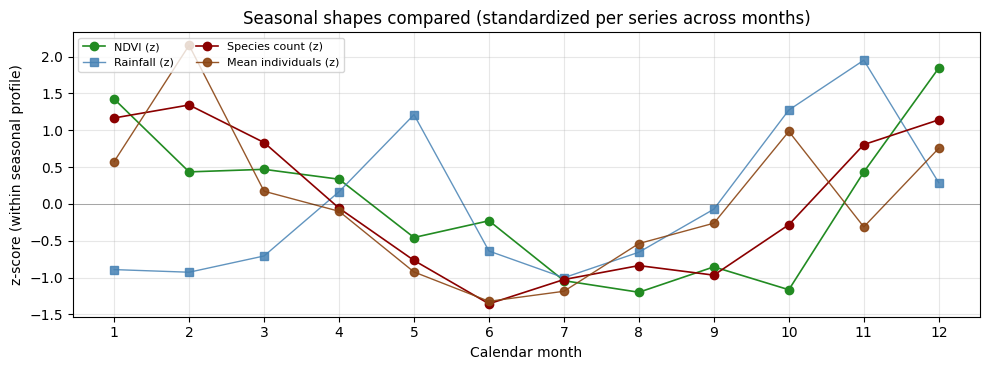

In [20]:
def z12(s):
    s = np.asarray(s, dtype=float)
    m, sd = np.nanmean(s), np.nanstd(s, ddof=1)
    if not np.isfinite(sd) or sd == 0:
        return np.zeros_like(s, dtype=float)
    return (s - m) / sd


fig, ax = plt.subplots(figsize=(10, 3.8))
ax.plot(months, z12(seasonal["NDVI_mean"]), "-o", color="forestgreen", lw=1.2, label="NDVI (z)")
ax.plot(months, z12(seasonal["rainfall_mean"]), "-s", color="steelblue", lw=1.0, alpha=0.85, label="Rainfall (z)")
ax.plot(months, z12(seasonal["species_n_mean"]), "-o", color="darkred", lw=1.2, label="Species count (z)")
ax.plot(
    months,
    z12(seasonal["mean_individual_mean"]),
    "-o",
    color="saddlebrown",
    lw=1.0,
    alpha=0.9,
    label="Mean individuals (z)",
)
ax.axhline(0, color="black", lw=0.5, alpha=0.4)
ax.set_xticks(x)
ax.set_xlabel("Calendar month")
ax.set_ylabel("z-score (within seasonal profile)")
ax.legend(loc="upper left", ncol=2, fontsize=8)
ax.set_title("Seasonal shapes compared (standardized per series across months)")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("images/veg_fig_seasonal_z_overlay.png", dpi=150, bbox_inches="tight")
plt.show()

**Spread across years:** boxplots of each year’s monthly value (one point per year per month).

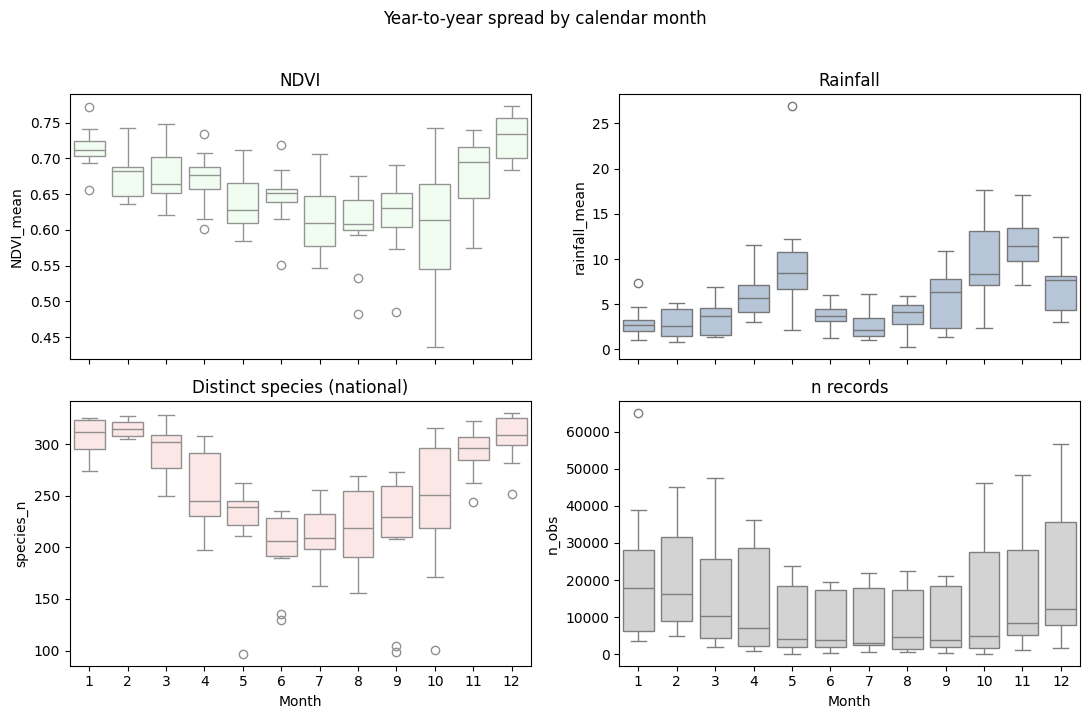

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(11, 7), sharex=True)
sns.boxplot(data=ym, x="cal_month", y="NDVI_mean", ax=axes[0, 0], color="honeydew")
axes[0, 0].set_title("NDVI")
sns.boxplot(data=ym, x="cal_month", y="rainfall_mean", ax=axes[0, 1], color="lightsteelblue")
axes[0, 1].set_title("Rainfall")
sns.boxplot(data=ym, x="cal_month", y="species_n", ax=axes[1, 0], color="mistyrose")
axes[1, 0].set_title("Distinct species (national)")
sns.boxplot(data=ym, x="cal_month", y="n_obs", ax=axes[1, 1], color="lightgray")
axes[1, 1].set_title("n records")
for ax in axes.ravel():
    ax.set_xlabel("Month")
fig.suptitle("Year-to-year spread by calendar month", y=1.02)
plt.tight_layout()
plt.savefig("images/veg_fig_seasonal_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()